In [74]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, r2_score
from sklearn.metrics import mean_squared_error as MSE
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV

In [3]:
data = pd.read_csv('/content/drive/MyDrive/ML-2025-spring/skempi_v2.csv', sep=';')
data

,#Pdb,Mutation(s)_PDB,Mutation(s)_cleaned,iMutation_Location(s),Hold_out_type,Hold_out_proteins,Affinity_mut (M),Affinity_mut_parsed,Affinity_wt (M),Affinity_wt_parsed,...,koff_mut_parsed,koff_wt (s^(-1)),koff_wt_parsed,dH_mut (kcal mol^(-1)),dH_wt (kcal mol^(-1)),dS_mut (cal mol^(-1) K^(-1)),dS_wt (cal mol^(-1) K^(-1)),Notes,Method,SKEMPI version
0,1CSE_E_I,LI45G,LI38G,COR,Pr/PI,Pr/PI,5.26E-11,5.260000e-11,1.12E-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IASP,1
1,1CSE_E_I,LI45S,LI38S,COR,Pr/PI,Pr/PI,8.33E-12,8.330000e-12,1.12E-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IASP,1
2,1CSE_E_I,LI45P,LI38P,COR,Pr/PI,Pr/PI,1.02E-07,1.020000e-07,1.12E-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IASP,1
3,1CSE_E_I,LI45I,LI38I,COR,Pr/PI,Pr/PI,1.72E-10,1.720000e-10,1.12E-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IASP,1
4,1CSE_E_I,LI45D,LI38D,COR,Pr/PI,Pr/PI,1.92E-09,1.920000e-09,1.12E-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IASP,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7080,3QIB_ABP_CD,KP9R,KP8R,COR,TCR/pMHC,"TCR/pMHC,1JCK_A_B",2.4E-04,2.400000e-04,5.5E-06,5.500000e-06,...,0.500,2.2E-02,0.022,NaN,NaN,NaN,NaN,NaN,SPR,2
7081,3QIB_ABP_CD,TP12A,TP11A,COR,TCR/pMHC,"TCR/pMHC,1JCK_A_B",>1.1E-03,1.100000e-03,5.5E-06,5.500000e-06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SPR,2
7082,3QIB_ABP_CD,TP12S,TP11S,COR,TCR/pMHC,"TCR/pMHC,1JCK_A_B",3.38E-05,3.380000e-05,5.5E-06,5.500000e-06,...,0.134,2.2E-02,0.022,NaN,NaN,NaN,NaN,NaN,SPR,2
7083,3QIB_ABP_CD,TP12N,TP11N,COR,TCR/pMHC,"TCR/pMHC,1JCK_A_B",4.34E-05,4.340000e-05,5.5E-06,5.500000e-06,...,0.175,2.2E-02,0.022,NaN,NaN,NaN,NaN,NaN,SPR,2


In [4]:
data.columns

Index(['#Pdb', 'Mutation(s)_PDB', 'Mutation(s)_cleaned',
       'iMutation_Location(s)', 'Hold_out_type', 'Hold_out_proteins',
       'Affinity_mut (M)', 'Affinity_mut_parsed', 'Affinity_wt (M)',
       'Affinity_wt_parsed', 'Reference', 'Protein 1', 'Protein 2',
       'Temperature', 'kon_mut (M^(-1)s^(-1))', 'kon_mut_parsed',
       'kon_wt (M^(-1)s^(-1))', 'kon_wt_parsed', 'koff_mut (s^(-1))',
       'koff_mut_parsed', 'koff_wt (s^(-1))', 'koff_wt_parsed',
       'dH_mut (kcal mol^(-1))', 'dH_wt (kcal mol^(-1))',
       'dS_mut (cal mol^(-1) K^(-1))', 'dS_wt (cal mol^(-1) K^(-1))', 'Notes',
       'Method', 'SKEMPI version'],
      dtype='object')

Свободная энергия Гиббса: $G=U+PV-TS$

Уравнение Гиббса-Гельмгольца: $dG = dH - TdS=RT\cdot ln(K_D)$,

где $K_D = k_{off}/k_{on}$

 $\Delta \Delta G = \Delta G_{mut}-\Delta G_{wt}$

 сначала попробуем обучить модель, пользуясь только численными столбцами, затем, если останется время, добавим категориальные признаки с помощью OneHotEncoder

 уберем Affinity Parced, потому что они сильноо коррелированы с обычными и могут мешать

In [87]:
data_new = data.drop(['#Pdb', 'Mutation(s)_PDB', 'Mutation(s)_cleaned',
                      'Protein 1', 'Protein 2',
                      'Notes', 'Method', 'SKEMPI version', 'Reference',
                      'Affinity_mut_parsed', 'Affinity_mut_parsed', 'Affinity_wt_parsed'
                      ], axis=1)

# в этом блоке я вытягиваю информацию из строк - аминокислота дикого типа и мутации и ее позиция
data_new['Old a.a.'] = data['Mutation(s)_PDB'].str[0].apply(ord)
data['New a.a.'] = data['Mutation(s)_PDB'].str[-1].apply(ord)
data_new['Mut. place'] = data['Mutation(s)_PDB'].str.extract(r"([-+]?\d*\.?\d+)")
data_new['iMutation_Location(s)'] = data_new['iMutation_Location(s)'].str[0] # тут для упрощения оставляю только одну - первую

# категоризируем превую мутацию
enc = OneHotEncoder(drop='first', sparse_output=False)
encoded_data = enc.fit_transform(data_new[['iMutation_Location(s)']])
encoded_df = pd.DataFrame(encoded_data, columns=enc.get_feature_names_out(['iMutation_Location(s)']))
data_new = pd.concat([data_new.reset_index(drop=True), encoded_df], axis=1)
data_new = data_new.drop(columns=['iMutation_Location(s)'])

data_new = data_new.drop(['Hold_out_type', 'Hold_out_proteins',
                      ], axis=1)

# в этом блоке я преобразую все строки, которые должны быть численными, в числа
data_new['Affinity_mut (M)'] = data_new['Affinity_mut (M)'].str.replace('E', 'e')
data_new['Affinity_wt (M)'] = data_new['Affinity_wt (M)'].str.replace('E', 'e')
data_new['koff_mut (s^(-1))'] = data_new['koff_mut (s^(-1))'].str.replace('E', 'e')
data_new['koff_wt (s^(-1))'] = data_new['koff_wt (s^(-1))'].str.replace('E', 'e')

data_new['Affinity_mut (M)'] = data_new['Affinity_mut (M)'].str.replace('>', '')
data_new['Affinity_wt (M)'] = data_new['Affinity_wt (M)'].str.replace('>', '')
data_new['Affinity_mut (M)'] = data_new['Affinity_mut (M)'].str.replace('<', '')
data_new['Affinity_wt (M)'] = data_new['Affinity_wt (M)'].str.replace('<', '')
data_new['Temperature'] = data_new['Temperature'].str.replace('(assumed)', '')

data_new['Affinity_mut (M)'] = pd.to_numeric(data_new['Affinity_mut (M)'], errors='coerce')
data_new['Affinity_wt (M)'] = pd.to_numeric(data_new['Affinity_wt (M)'], errors='coerce')
data_new['Temperature'] = pd.to_numeric(data_new['Temperature'], errors='coerce')
data_new['koff_mut (s^(-1))'] = pd.to_numeric(data_new['koff_mut (s^(-1))'], errors='coerce')
data_new['koff_wt (s^(-1))'] = pd.to_numeric(data_new['koff_wt (s^(-1))'], errors='coerce')

data_new

,Affinity_mut (M),Affinity_wt (M),Temperature,kon_mut (M^(-1)s^(-1)),kon_mut_parsed,kon_wt (M^(-1)s^(-1)),kon_wt_parsed,koff_mut (s^(-1)),koff_mut_parsed,koff_wt (s^(-1)),...,dH_mut (kcal mol^(-1)),dH_wt (kcal mol^(-1)),dS_mut (cal mol^(-1) K^(-1)),dS_wt (cal mol^(-1) K^(-1)),New a.a.,Old a.a.,Mut. place,iMutation_Location(s)_I,iMutation_Location(s)_R,iMutation_Location(s)_S
0,5.260000e-11,1.120000e-12,294.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,71,76,45,0.0,0.0,0.0
1,8.330000e-12,1.120000e-12,294.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,83,76,45,0.0,0.0,0.0
2,1.020000e-07,1.120000e-12,294.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,80,76,45,0.0,0.0,0.0
3,1.720000e-10,1.120000e-12,294.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,73,76,45,0.0,0.0,0.0
4,1.920000e-09,1.120000e-12,294.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,68,76,45,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7080,2.400000e-04,5.500000e-06,298.0,2070.0,2070.0,4000.0,4000.0,0.500,0.500,0.022,...,NaN,NaN,NaN,NaN,82,75,9,0.0,0.0,0.0
7081,1.100000e-03,5.500000e-06,298.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,65,84,12,0.0,0.0,0.0
7082,3.380000e-05,5.500000e-06,298.0,3960.0,3960.0,4000.0,4000.0,0.134,0.134,0.022,...,NaN,NaN,NaN,NaN,83,84,12,0.0,0.0,0.0
7083,4.340000e-05,5.500000e-06,298.0,4030.0,4030.0,4000.0,4000.0,0.175,0.175,0.022,...,NaN,NaN,NaN,NaN,78,84,12,0.0,0.0,0.0


In [88]:
nan_counts = data_new.isna().sum() # проверяю насколько все плохо с разными признаками
print(nan_counts)
print(data_new.shape)

Affinity_mut (M)                 286
Affinity_wt (M)                    2
Temperature                        4
kon_mut (M^(-1)s^(-1))          5241
kon_mut_parsed                  5241
kon_wt (M^(-1)s^(-1))           5232
kon_wt_parsed                   5232
koff_mut (s^(-1))               5259
koff_mut_parsed                 5241
koff_wt (s^(-1))                5226
koff_wt_parsed                  5225
dH_mut (kcal mol^(-1))          6642
dH_wt (kcal mol^(-1))           6642
dS_mut (cal mol^(-1) K^(-1))    6642
dS_wt (cal mol^(-1) K^(-1))     6642
New a.a.                           0
Old a.a.                           0
Mut. place                         0
iMutation_Location(s)_I            0
iMutation_Location(s)_R            0
iMutation_Location(s)_S            0
dtype: int64
(7085, 21)


In [89]:
data_new = data_new.dropna(subset=['Temperature', 'Affinity_wt (M)', 'Affinity_mut (M)']) # убираю те Nan'ы, которые не позволят мне посчитать ddG
nan_counts = data_new.isna().sum()
print(nan_counts)
print(data_new.shape)

Affinity_mut (M)                   0
Affinity_wt (M)                    0
Temperature                        0
kon_mut (M^(-1)s^(-1))          4949
kon_mut_parsed                  4949
kon_wt (M^(-1)s^(-1))           4949
kon_wt_parsed                   4949
koff_mut (s^(-1))               4967
koff_mut_parsed                 4949
koff_wt (s^(-1))                4943
koff_wt_parsed                  4942
dH_mut (kcal mol^(-1))          6350
dH_wt (kcal mol^(-1))           6350
dS_mut (cal mol^(-1) K^(-1))    6350
dS_wt (cal mol^(-1) K^(-1))     6350
New a.a.                           0
Old a.a.                           0
Mut. place                         0
iMutation_Location(s)_I            0
iMutation_Location(s)_R            0
iMutation_Location(s)_S            0
dtype: int64
(6793, 21)


как видно, просто удалять Nan'ы не получится, так как для многих параметров они занимают почти всю таблицу. Сделаем посчет $\Delta \Delta G$ доступным способом для каждой строки: $\Delta \Delta G = RTln(\frac{K_{D-mut}}{K_{D-wt}})$

In [90]:
for column in data_new.columns:
    if data_new[column].dtype != np.float64:
      print(column)

New a.a.
Old a.a.
Mut. place


In [91]:
data_new['ddG'] = 8.31 * data_new['Temperature'] * (np.log(data_new['Affinity_mut (M)']) - np.log(data_new['Affinity_wt (M)'])) #выбранная формула для подсчета ddG
data_neww = data_new.drop(['Temperature', 'Affinity_wt (M)', 'Affinity_mut (M)'], axis=1) # нужно убрать те параметры, по которым напрямую считалась ddG,
                                                                                         # иначе смысл задачи пропадает - зависимости очень простые
data_neww

<ipython-input-91-30b488634756>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_new['ddG'] = 8.31 * data_new['Temperature'] * (np.log(data_new['Affinity_mut (M)']) - np.log(data_new['Affinity_wt (M)']))


,kon_mut (M^(-1)s^(-1)),kon_mut_parsed,kon_wt (M^(-1)s^(-1)),kon_wt_parsed,koff_mut (s^(-1)),koff_mut_parsed,koff_wt (s^(-1)),koff_wt_parsed,dH_mut (kcal mol^(-1)),dH_wt (kcal mol^(-1)),dS_mut (cal mol^(-1) K^(-1)),dS_wt (cal mol^(-1) K^(-1)),New a.a.,Old a.a.,Mut. place,iMutation_Location(s)_I,iMutation_Location(s)_R,iMutation_Location(s)_S,ddG
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71,76,45,0.0,0.0,0.0,9404.592417
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83,76,45,0.0,0.0,0.0,4902.245360
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,80,76,45,0.0,0.0,0.0,27899.191467
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,73,76,45,0.0,0.0,0.0,12299.171812
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68,76,45,0.0,0.0,0.0,18193.457143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7080,2070.0,2070.0,4000.0,4000.0,0.500,0.500,0.022,0.022,NaN,NaN,NaN,NaN,82,75,9,0.0,0.0,0.0,9350.540536
7081,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65,84,12,0.0,0.0,0.0,13120.647160
7082,3960.0,3960.0,4000.0,4000.0,0.134,0.134,0.022,0.022,NaN,NaN,NaN,NaN,83,84,12,0.0,0.0,0.0,4496.394641
7083,4030.0,4030.0,4000.0,4000.0,0.175,0.175,0.022,0.022,NaN,NaN,NaN,NaN,78,84,12,0.0,0.0,0.0,5115.486270


In [51]:
X = data_neww.drop('ddG', axis=1)
y = (data_neww['ddG'] > 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5094, 18), (1699, 18), (5094,), (1699,))

In [52]:
forest1 = RandomForestClassifier(n_estimators=100) #обучим случайный лес, чтобы посмотреть на влияние параметров на предсказание
forest1.fit(X_train, y_train)

RandomForestClassifier()

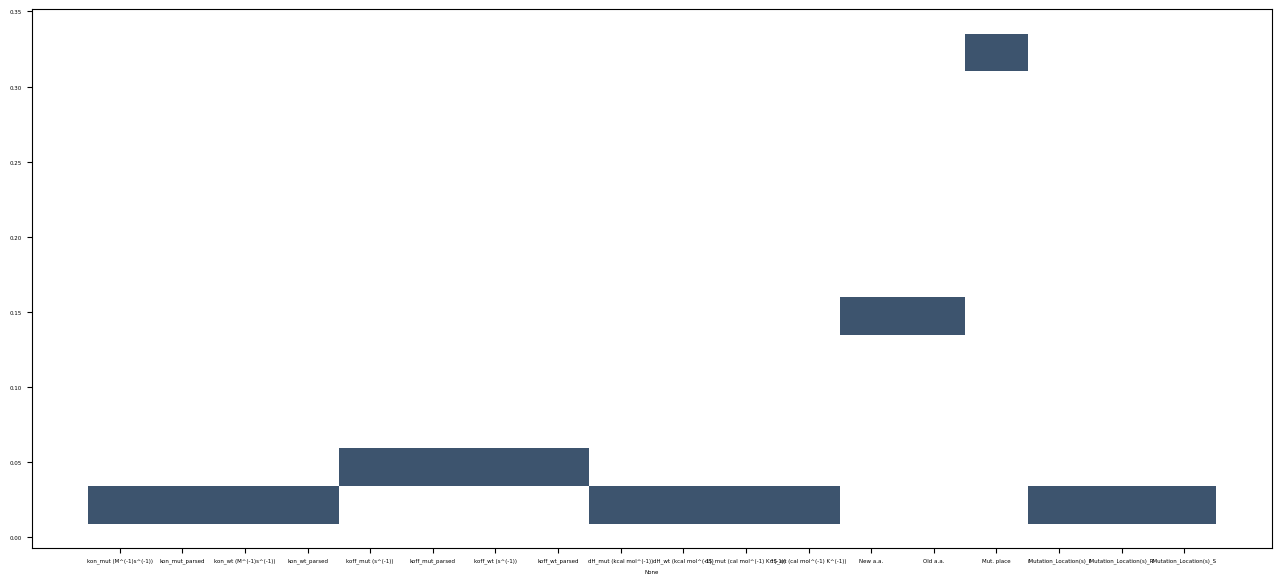

In [55]:
plt.figure(figsize=(16, 7))
sns.histplot(x = X.columns, y=forest1.feature_importances_, fill=False)
plt.rcParams['font.size'] = 10


In [56]:
y_pred = forest1.predict(X_test) # любопытства ради решила посмотреть на точность такого леса
accuracy_score(y_test, y_pred)

0.8263684520306063

В целом выглядит уже вполне хорошо. Попробуем применить бустинг и посмотреть на то, как изменится качество модели

In [81]:
grid = {'learning_rate': [0.01, 0.05, 0.01],
        'max_iter': [100, 300, 500],
        'max_depth': [10, 20, 30, 40]

}

boost_search = RandomizedSearchCV(estimator=HistGradientBoostingClassifier(), param_distributions=grid, n_iter=20)
boost_search.fit(X_train, y_train)


RandomizedSearchCV(estimator=HistGradientBoostingClassifier(), n_iter=20,
                   param_distributions={'learning_rate': [0.01, 0.05, 0.01],
                                        'max_depth': [10, 20, 30, 40],
                                        'max_iter': [100, 300, 500]})

In [82]:
y_pred = boost_search.predict(X_test)
accuracy_score(y_test, y_pred)

0.8463802236609771

Видно, что результат стал точннее, но ненамного. В целом показатели все равно хорошие, но возможно получится лучше. Для этого оставим только параметры с более высокими feature_importances и посмотрим еще раз.

In [83]:
feats = ['koff_mut (s^(-1))', 'koff_wt (s^(-1))', 'koff_wt_parsed', 'New a.a.', 'Old a.a.', 'Mut. place']
X_train, X_test = X_train[feats], X_test[feats]

In [84]:
grid = {'learning_rate': [0.01, 0.05, 0.01],
        'max_iter': [100, 300, 500],
        'max_depth': [10, 20, 30, 40]

}

boost_search = RandomizedSearchCV(estimator=HistGradientBoostingClassifier(), param_distributions=grid, n_iter=20)
boost_search.fit(X_train, y_train)

RandomizedSearchCV(estimator=HistGradientBoostingClassifier(), n_iter=20,
                   param_distributions={'learning_rate': [0.01, 0.05, 0.01],
                                        'max_depth': [10, 20, 30, 40],
                                        'max_iter': [100, 300, 500]})

In [85]:
y_pred = boost_search.predict(X_test)
accuracy_score(y_test, y_pred)

0.8269570335491465

Видно, что такое действие не принесло улучшения в предсказание. Наконец, попробуем предсказать знак $\Delta \Delta G$ с параметрами, использованными для подсчета -- скорее всего увидим что-то очень близкое к 100

In [92]:
X = data_new.drop('ddG', axis=1)
y = (data_new['ddG'] > 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

grid = {'learning_rate': [0.01, 0.05, 0.01],
        'max_iter': [100, 300, 500],
        'max_depth': [10, 20, 30, 40]

}

boost_search = RandomizedSearchCV(estimator=HistGradientBoostingClassifier(), param_distributions=grid, n_iter=20)
boost_search.fit(X_train, y_train)

y_pred = boost_search.predict(X_test)
accuracy_score(y_test, y_pred)

0.9817539729252501

Как и ожидалось, точность очень высокая.

В результате: accuracy score 84.6% без параметров температуры и $K_D$, 98.1% с ними